In [2]:
# Importing necessary libraries for EDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [11]:
# Load the dataset
data = pd.read_csv('data/data.csv', encoding='ascii')

# Display basic information about the dataset
print('Dataset Info:')
data.info()

# Display the first few rows of the dataset
print('\
Dataset Head:')
print(data.head())
# Summary statistics for numerical features
print("### Summary Statistics ###\n")
print(data.describe())


# Display summary statistics


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  
 15  Fraud

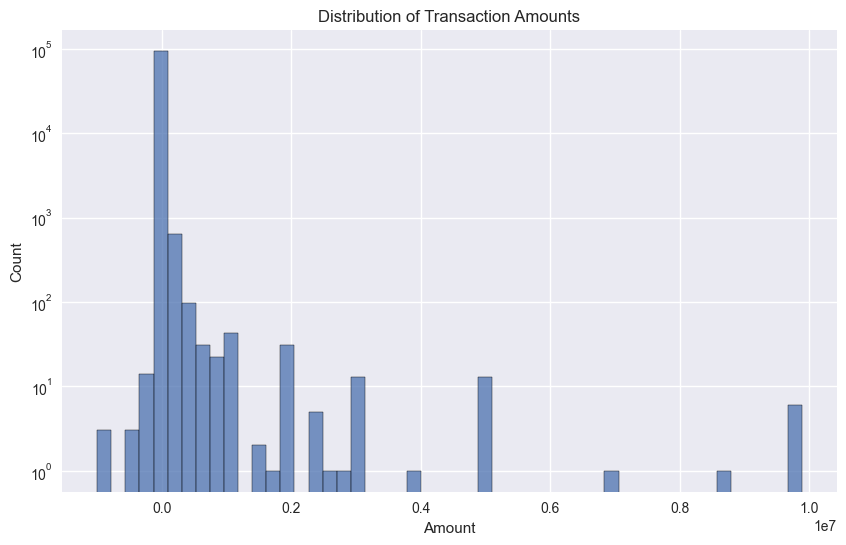

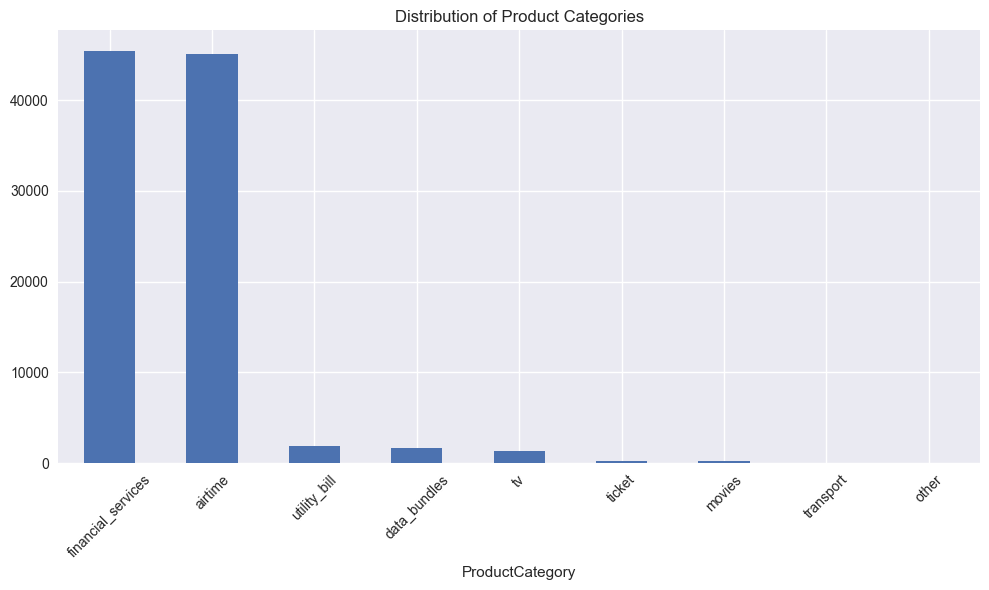

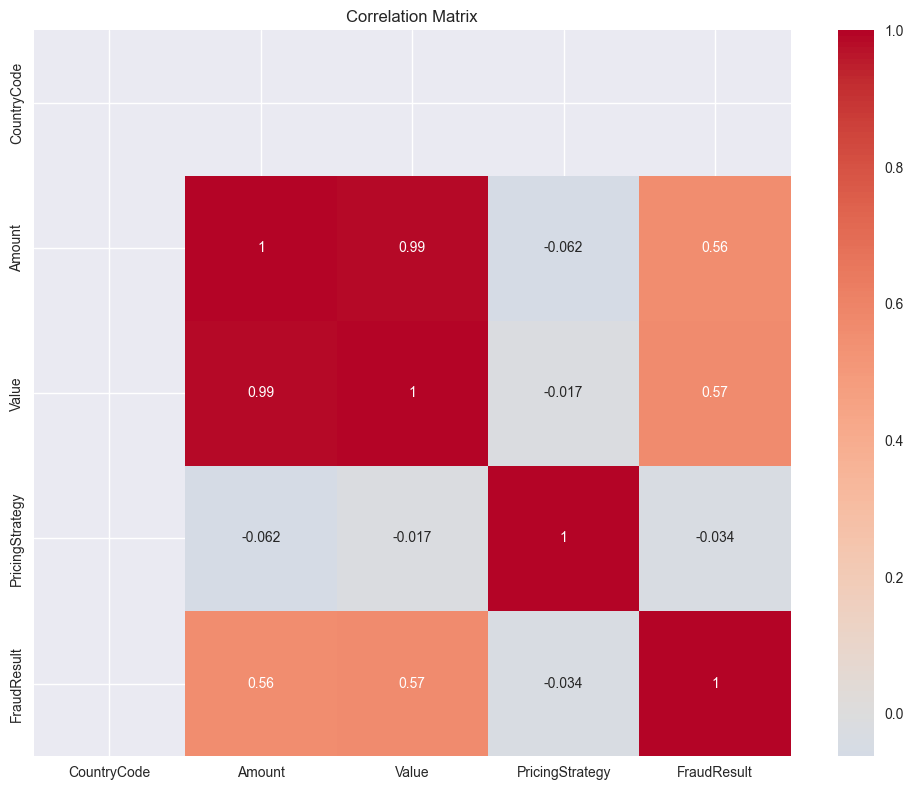

Missing Values:
TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64


In [12]:
# Set style for better visualizations
plt.style.use('seaborn-v0_8')

# Distribution of Amount
plt.figure(figsize=(10, 6))
sns.histplot(data['Amount'], bins=50)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.yscale('log')
plt.show()

# Distribution of Product Categories
plt.figure(figsize=(10, 6))
data['ProductCategory'].value_counts().plot(kind='bar')
plt.title('Distribution of Product Categories')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation matrix for numerical columns
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = data[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Missing values check
print('\
Missing Values:')
print(data.isnull().sum())

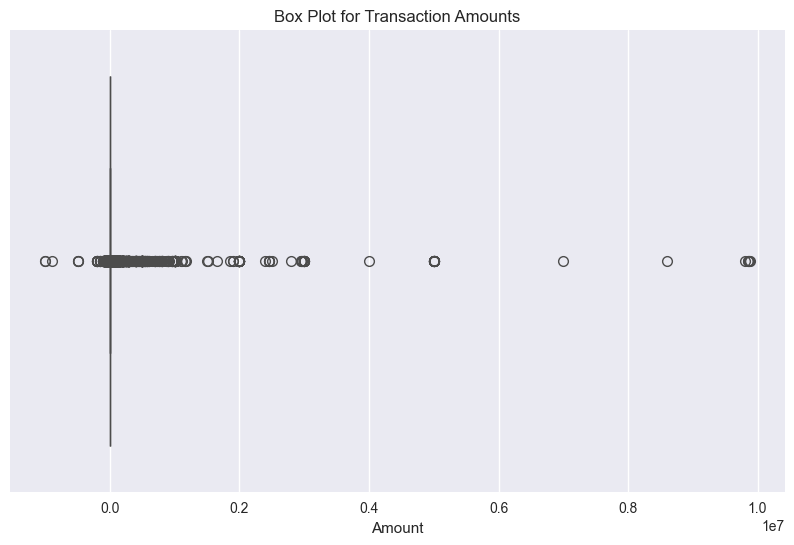

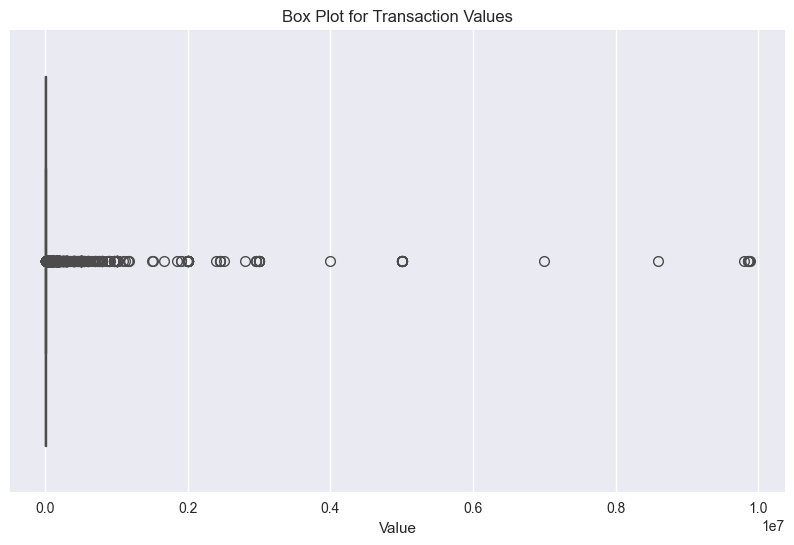

In [13]:
# Box plot for outlier detection in the 'Amount' column
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['Amount'])
plt.title('Box Plot for Transaction Amounts')
plt.xlabel('Amount')
plt.show()

# Box plot for outlier detection in the 'Value' column
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['Value'])
plt.title('Box Plot for Transaction Values')
plt.xlabel('Value')
plt.show()

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distributions of numerical features
numerical_features = ['Amount', 'Value', 'FraudResult']

plt.figure(figsize=(15, 5))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(1, 3, i)
    sns.histplot(data[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


### Analysis of Amount ###
- The distribution is likely skewed due to large transaction values.
- Negative values indicate refunds or deductions.
- Presence of extreme outliers (as seen from min/max stats).
Plot saved as: Amount_distribution.png

### Analysis of Value ###
- Similar distribution to 'Amount' but strictly positive.
- Represents absolute transaction values.
- Likely skewed and contains large values.
Plot saved as: Value_distribution.png

### Analysis of FraudResult ###
- Binary distribution with most values being 0 (non-fraud).
- Very few instances of fraud (1), confirming dataset imbalance.
Plot saved as: FraudResult_distribution.png



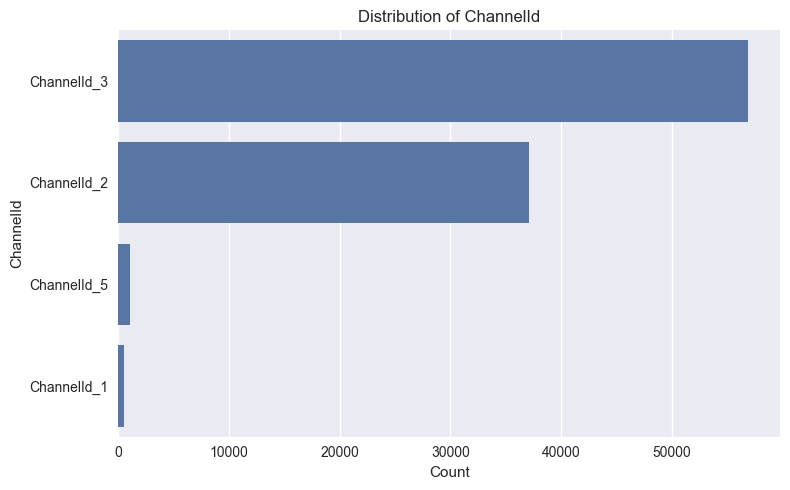

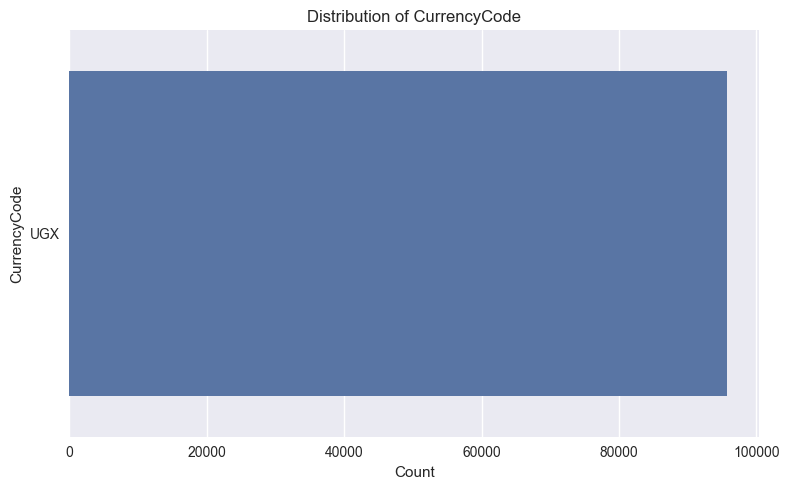

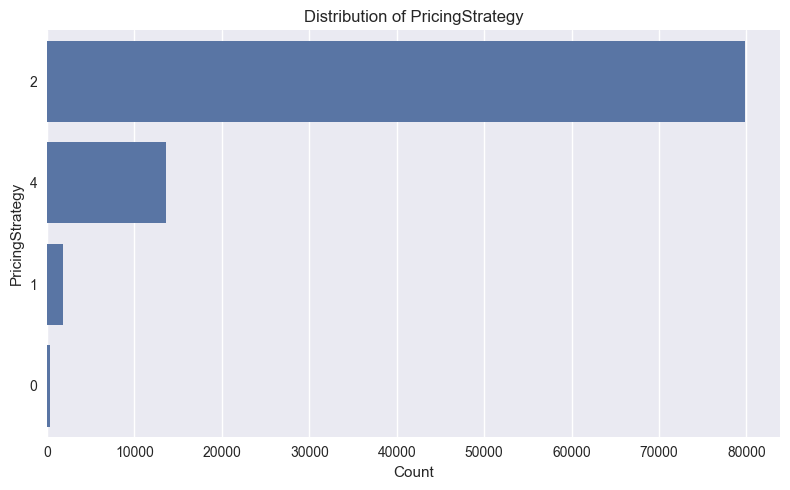

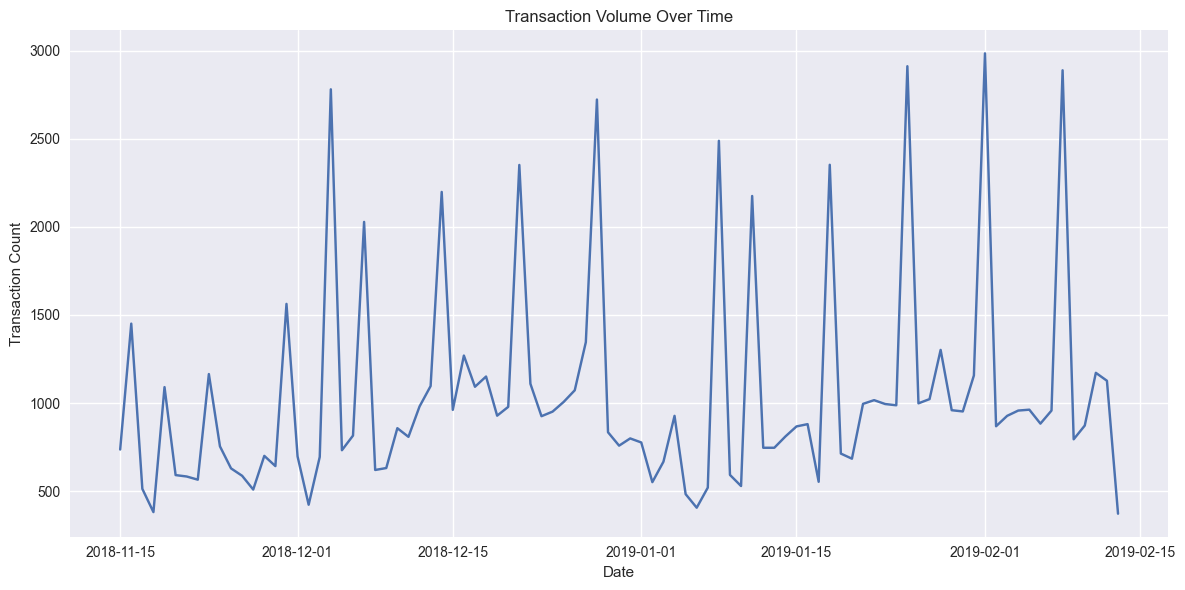

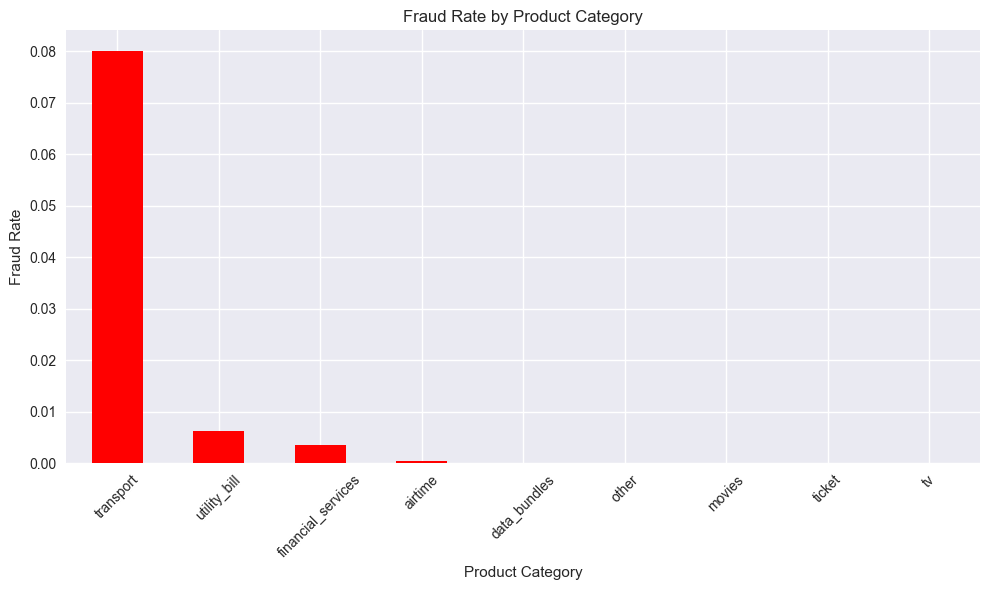

In [18]:
# Further categorical analysis
categorical_features = ['ChannelId', 'CurrencyCode', 'PricingStrategy']

for feature in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=data, y=feature, order=data[feature].value_counts().index)
    plt.title(f'Distribution of {feature}')
    plt.xlabel('Count')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

# Time-based analysis
data['TransactionStartTime'] = pd.to_datetime(data['TransactionStartTime'])
data['TransactionDate'] = data['TransactionStartTime'].dt.date

plt.figure(figsize=(12, 6))
data['TransactionDate'].value_counts().sort_index().plot()
plt.title('Transaction Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Transaction Count')
plt.tight_layout()
plt.show()

# Fraud Analysis by ProductCategory
plt.figure(figsize=(10, 6))
fraud_by_category = data.groupby('ProductCategory')['FraudResult'].mean().sort_values(ascending=False)
fraud_by_category.plot(kind='bar', color='red')
plt.title('Fraud Rate by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
